In [2]:
include("/home/Arpan/orbit/FUNCTIONS/Satellite.jl")
include("/home/Arpan/orbit/FUNCTIONS/Time.jl")
include("/home/Arpan/orbit/FUNCTIONS/coordinates.jl")
include("/home/Arpan/orbit/FUNCTIONS/Rotations.jl")
include("/home/Arpan/orbit/FUNCTIONS/SolveKepler.jl")
include("/home/Arpan/orbit/FUNCTIONS/Results.jl")
include("Pertubations.jl")
include("/home/Arpan/orbit/FUNCTIONS/Propagation.jl")
include("/home/Arpan/orbit/FUNCTIONS/Plotting.jl")

plot_groundtrack

In [3]:
# Earth Constants
GM = 398600.4418          # km³/s²
ωE = 7.2921150e-5         # rad/s

7.292115e-5

In [4]:
champ = Satellite(
    "CHAMP",
    6838.0,
    0.004,
    deg2rad(87.0),
    deg2rad(0.0),
    deg2rad(0.0),
    deg2rad(0.0)
)

Satellite("CHAMP", 6838.0, 0.004, 1.5184364492350666, 0.0, 0.0, 0.0)

In [5]:
result_j2 = propagate_j2(
    champ,
    GM,
    ωE;
    dt = 10.0,
    revolutions = 2
)

PropagationResult([0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0  …  11160.0, 11170.0, 11180.0, 11190.0, 11200.0, 11210.0, 11220.0, 11230.0, 11240.0, 11250.0], [6810.648 6810.219539546645 … 6806.6660277016135 6808.849145484516; 0.0 4.000531603100641 … -18.495316989606238 -14.498372694216958; 0.0 76.44197940961882 … -232.38154955026107 -155.9694164569807], [0.0 -0.08581118689040423 … 0.2615041753630385 0.17572689313041384; 0.4011822322212066 0.4011570642155405 … 0.4007063595885619 0.4009140392446814; 7.655013009700744 7.654531423661479 … 7.650560147512882 7.653006759308764], [6810.648 6810.220646115001 … 4631.956275293591 4632.730166648336; 0.0 -0.9655594261823293 … -4987.587147427715 -4989.834475391191; 0.0 76.44197940961882 … -232.38154955026107 -155.9694164569807], [0.0, 0.6430949973369215, 1.286189123439919, 1.9292815069386147, 2.572371276189238, 3.2154575591367176, 3.858539483175297, 4.50161617500719, 5.144686760498797, 5.787750364533895  …  -7.099924343203906, -6.45687

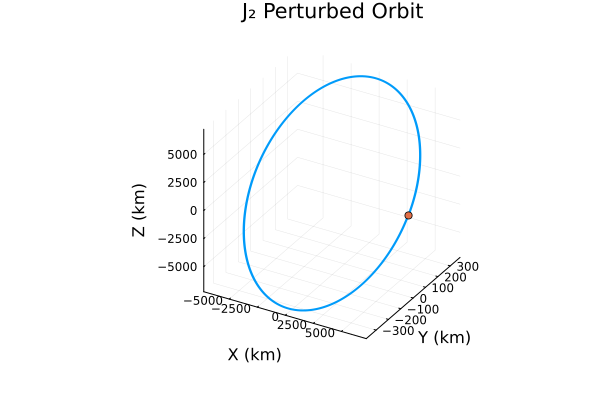

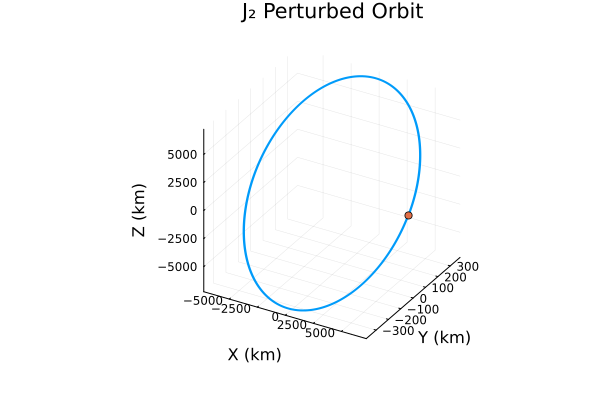

In [6]:
plot_orbit(
    result_j2.positions_eci;
    title = "J₂ Perturbed Orbit"
)

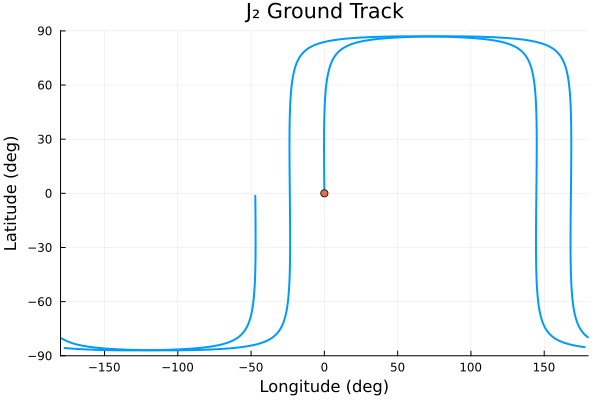

"/home/Arpan/orbit/HW2/J2champgroundtrack.png"

In [9]:
p1 = plot_groundtrack(
    result_j2.latitudes,
    result_j2.longitudes;
    title = "J₂ Ground Track"
)
savefig(p1, "J2champgroundtrack.png")

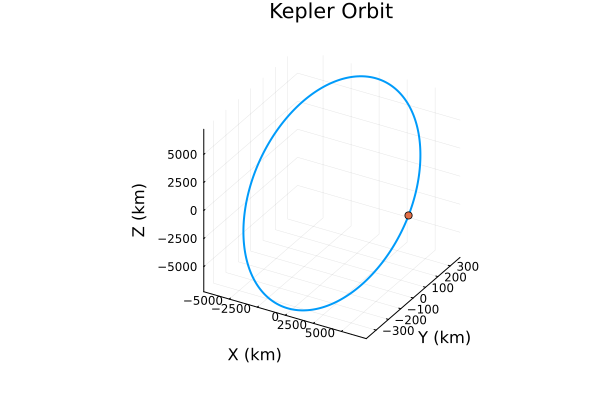

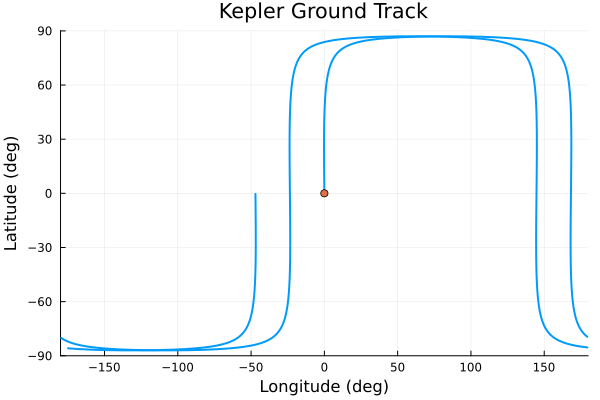

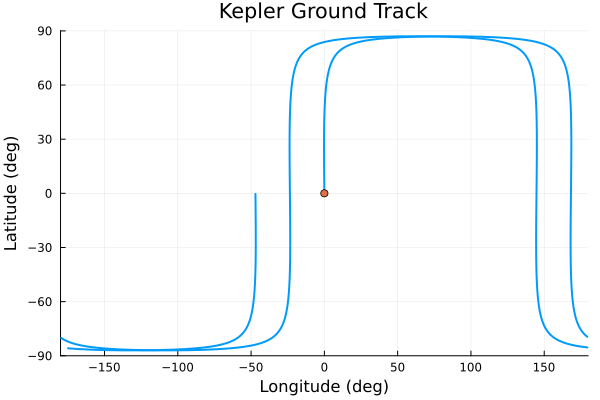

In [11]:
result_kepler = propagate_kepler(
    champ,
    GM,
    ωE;
    dt = 10.0,
    revolutions = 2
)
plot_orbit(
    result_kepler.positions_eci;
    title = "Kepler Orbit"
)
plot_groundtrack(
    result_kepler.latitudes,
    result_kepler.longitudes;
    title = "Kepler Ground Track"
)

In [13]:
Δr = zeros(length(result_kepler.time))

for k in eachindex(Δr)
    Δr[k] = norm(
        result_j2.positions_eci[:,k] -
        result_kepler.positions_eci[:,k]
    )
end

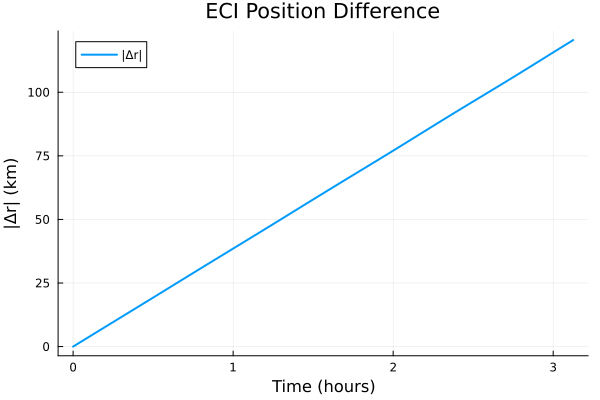

In [20]:
plot(
    result_kepler.time ./ 3600,
    Δr,
    label = "|Δr|",
    xlabel = "Time (hours)",
    ylabel = "|Δr| (km)",
    linewidth = 2,
    title = "ECI Position Difference"
)

In [15]:
Ωdot, ωdot, Mdot = compute_j2_secular_rates(
    champ.a,
    champ.e,
    champ.i
)

println("RAAN Rate = ", rad2deg(Ωdot) * 86400, " deg/day")

println("Perigee Rate = ", rad2deg(ωdot) * 86400, " deg/day")

RAAN Rate = -0.4087205647280031 deg/day
Perigee Rate = -3.8513008896780874 deg/day


In [ ]:
sat0 = propagate_j2_elements(champ, 0.0)

sat1 = propagate_j2_elements(champ, 86400.0)   # 1 day

println("Initial RAAN  = ", rad2deg(sat0.Ω))
println("Final RAAN    = ", rad2deg(sat1.Ω))
println("Difference    = ", rad2deg(sat1.Ω - sat0.Ω))

println()

println("Initial ω     = ", rad2deg(sat0.ω))
println("Final ω       = ", rad2deg(sat1.ω))
println("Difference    = ", rad2deg(sat1.ω - sat0.ω))

Initial RAAN  = 0.0
Final RAAN    = -0.40872056472800317
Difference    = -0.40872056472800317

Initial ω     = 0.0
Final ω       = -3.851300889678087
Difference    = -3.851300889678087


In [17]:
sat1 = propagate_j2_elements(champ, 0)

sat2 = propagate_j2_elements(champ, 3 * 3600)

println(rad2deg(sat1.Ω))

println(rad2deg(sat2.Ω))

0.0
-0.051090070591000396


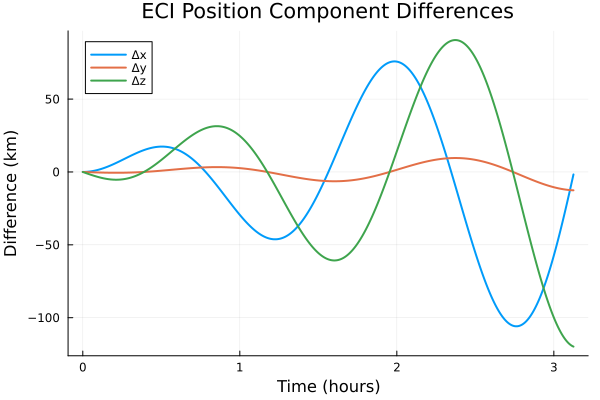

In [31]:
Δx = result_j2.positions_eci[1, :] .- result_kepler.positions_eci[1, :]
Δy = result_j2.positions_eci[2, :] .- result_kepler.positions_eci[2, :]
Δz = result_j2.positions_eci[3, :] .- result_kepler.positions_eci[3, :]

t = result_kepler.time ./ 3600   # hours

p = plot(
    t,
    Δx,
    label = "Δx",
    xlabel = "Time (hours)",
    ylabel = "Difference (km)",
    linewidth = 2,
    title = "ECI Position Component Differences"
)

plot!(p, t, Δy, label = "Δy", linewidth = 2)
plot!(p, t, Δz, label = "Δz", linewidth = 2)

display(p)

In [21]:
using Plots

# Semi-major axis range [km]
a_values = 6600.0:25.0:9000.0

Ωdot = Float64[]
ωdot = Float64[]

# Keep CHAMP values fixed
e = champ.e
i = champ.i

for a in a_values

    Ω, ω, _ = compute_j2_secular_rates(a, e, i)

    push!(Ωdot, rad2deg(Ω) * 86400)
    push!(ωdot, rad2deg(ω) * 86400)

end

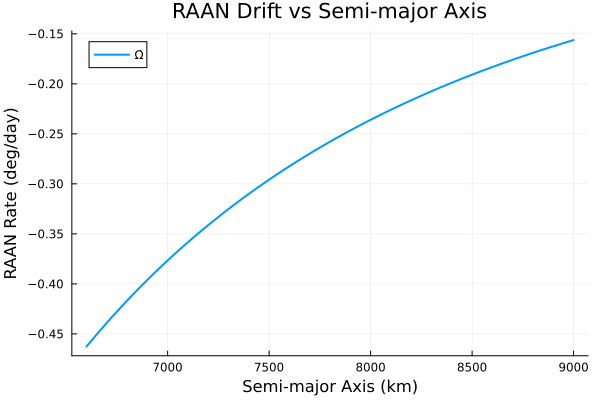

In [23]:
plot(
    a_values,
    Ωdot,
    xlabel = "Semi-major Axis (km)",
    ylabel = "RAAN Rate (deg/day)",
    linewidth = 2,
    label = "Ω̇",
    title = "RAAN Drift vs Semi-major Axis"
)


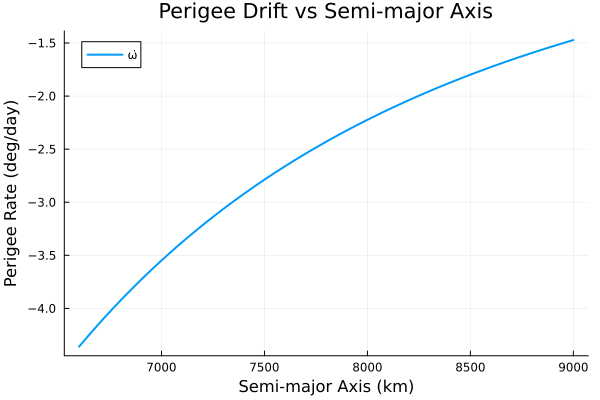

In [24]:

plot(
    a_values,
    ωdot,
    xlabel = "Semi-major Axis (km)",
    ylabel = "Perigee Rate (deg/day)",
    linewidth = 2,
    label = "ω̇",
    title = "Perigee Drift vs Semi-major Axis"
)

In [25]:
# Eccentricity range
e_values = 0.0:0.01:0.9

Ωdot = Float64[]
ωdot = Float64[]

a = champ.a
i = champ.i

for e in e_values

    Ω, ω, _ = compute_j2_secular_rates(a, e, i)

    push!(Ωdot, rad2deg(Ω) * 86400)
    push!(ωdot, rad2deg(ω) * 86400)

end

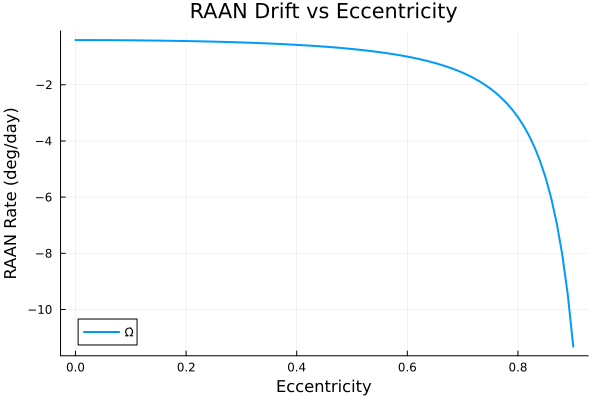

In [26]:
plot(
    e_values,
    Ωdot,
    xlabel = "Eccentricity",
    ylabel = "RAAN Rate (deg/day)",
    linewidth = 2,
    label = "Ω̇",
    title = "RAAN Drift vs Eccentricity"
)

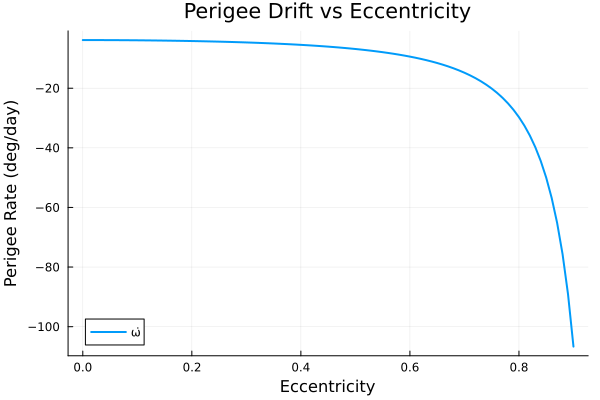

In [27]:
plot(
    e_values,
    ωdot,
    xlabel = "Eccentricity",
    ylabel = "Perigee Rate (deg/day)",
    linewidth = 2,
    label = "ω̇",
    title = "Perigee Drift vs Eccentricity"
)

In [28]:
i_values = deg2rad.(0.0:1.0:180.0)

Ωdot = Float64[]
ωdot = Float64[]

a = champ.a
e = champ.e

for i in i_values

    Ω, ω, _ = compute_j2_secular_rates(a, e, i)

    push!(Ωdot, rad2deg(Ω) * 86400)
    push!(ωdot, rad2deg(ω) * 86400)

end

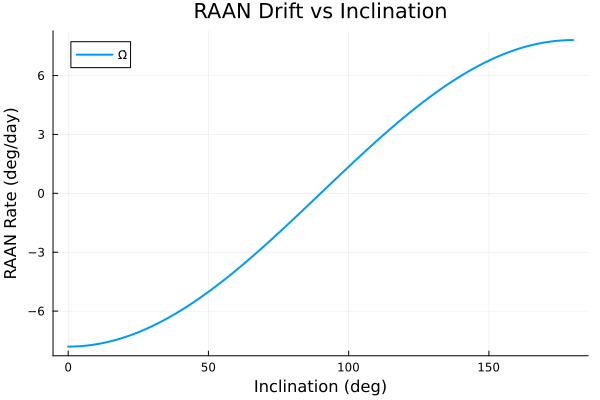

In [29]:
plot(
    rad2deg.(i_values),
    Ωdot,
    xlabel = "Inclination (deg)",
    ylabel = "RAAN Rate (deg/day)",
    linewidth = 2,
    label = "Ω̇",
    title = "RAAN Drift vs Inclination"
)

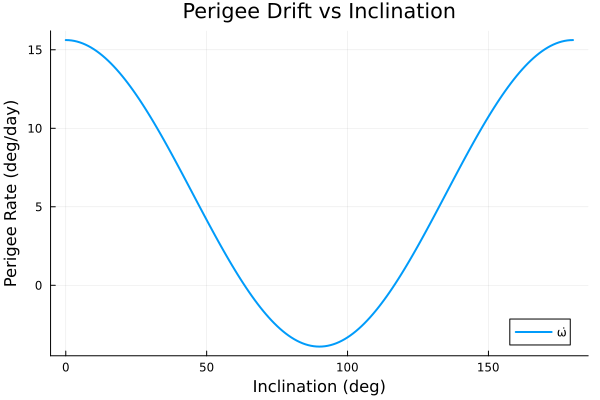

In [30]:
plot(
    rad2deg.(i_values),
    ωdot,
    xlabel = "Inclination (deg)",
    ylabel = "Perigee Rate (deg/day)",
    linewidth = 2,
    label = "ω̇",
    title = "Perigee Drift vs Inclination"
)